In [1122]:
import numpy as np
import matplotlib.pyplot as plt

# car data

In [1123]:
weight = 1200 #kg
c_d = 0.33
frontal = 1.79 #m^2
wheel_radius = 0.33 #m
tyre_coeff = 0.8

# gearbox

In [1124]:
final_drive = 3.3
gear_1 = 3.81
gear_2 = 2.61
gear_3 = 1.91
gear_4 = 1.48
gear_5 = 1.16
gear_6 = 0.91

gear_index = 0
max_gear = 5
gear = [gear_1, gear_2, gear_3, gear_4, gear_5, gear_6]

# engine model

very simple engine torque model, will replace with something better later

In [1125]:
torque = lambda N: 500*np.sin(.0003*N)
hp = lambda N: torque(N) * N / 5252

engine_speed_list = np.linspace(1500,7800,600)

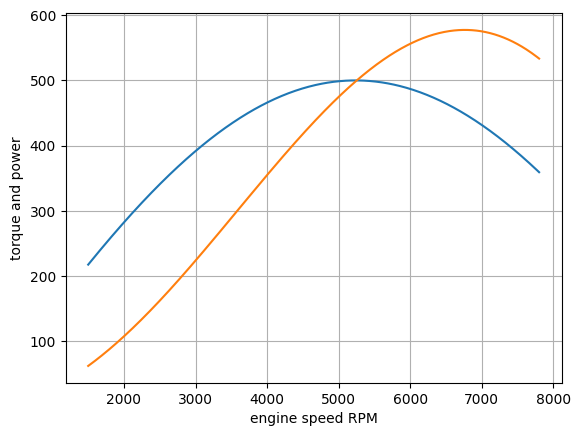

In [1126]:
plt.plot(engine_speed_list, torque(engine_speed_list))
plt.plot(engine_speed_list, hp(engine_speed_list))
plt.xlabel("engine speed RPM")
plt.ylabel("torque and power")
plt.grid()
plt.show()

# forces

force at ground takes into account the friction limit of the tires

load transfer onto and off the driving wheels is not simulated yet

In [1127]:
torque_at_wheel_axis = lambda N, gear_index: 0.86 * torque(N) * gear[gear_index] * final_drive
def force_at_ground(N, gear_index) :
    return min(torque_at_wheel_axis(N, gear_index) / wheel_radius, 0.6 * weight * 9.81 * tyre_coeff)

drag = lambda speed: 0.5 * c_d * frontal * 1.2 * speed**2
roll_resistance = lambda speed: (1e-2 + 5e-7 * speed /3.6 + 2e-7 * speed**2 /3.6**2) * 9.81 * weight

In [1128]:
def f(t,speed,N, gear_index): 
    return (force_at_ground(N, gear_index) - drag(speed) - roll_resistance(speed))/weight


In [1129]:
# find engine speed from vehicle speed
get_RPM = lambda speed, gear_index: speed * 30 * gear[gear_index] * final_drive /(np.pi * wheel_radius)

- start with u = 0, t=0 and 1st gear with N = 3000
- find next u i+1
- from the new u find new engine speed
- use the new engine speed to find the new torque and use that torque for u i+2

# results

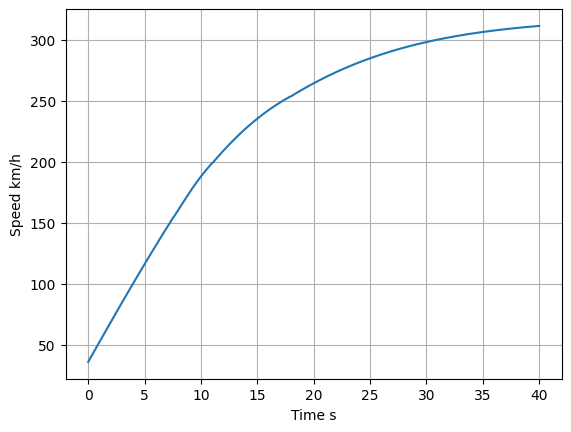

0.0 36.0
0.08016032064128256 37.31905150491795
0.16032064128256512 38.63745652516726
0.24048096192384769 39.95519256069001
0.32064128256513025 41.272237157577706
0.4008016032064128 42.588567909583176
0.48096192384769537 43.904162459625546
0.561122244488978 45.218998501288006
0.6412825651302605 46.53305378030824
0.721442885771543 47.84630609606127
0.8016032064128256 49.158733303034495
0.8817635270541082 50.47031331229477
0.9619238476953907 51.781024092947234
1.0420841683366733 53.09084367358582
1.122244488977956 54.39975014373511
1.2024048096192383 55.707721655283436
1.282565130260521 57.014736423906996
1.3627254509018036 58.32077273048477
1.442885771543086 59.62580892250411
1.5230460921843687 60.92982341545677
1.6032064128256511 62.23279469422515
1.6833667334669338 63.53470131445872
1.7635270541082164 64.83552190394026
1.8436873747494988 66.13523516394189
1.9238476953907815 67.43381987057056
2.004008016032064 68.73125487610302
2.0841683366733466 70.02751911030995
2.164328657314629 71.3

In [1130]:
end = 40 #s
max_steps = 500
time = np.linspace(0,end,max_steps) # s
step = end/max_steps

# cache
speed = np.zeros(max_steps) # m/s
speed[0] = 10
N = get_RPM(speed[0], gear_index)
N_s = [N]
tire_forces = [force_at_ground(N, gear_index)]
torque_at_wheel_list = [torque_at_wheel_axis(N, gear_index)]
crank_torque_list = [torque(N)]
gear_list = [gear_index]

for i in range(1,max_steps):
    #euler
    #speed[i] = speed[i-1] + step*f(time[i-1], speed[i-1],N, gear_index)
    k1 = step * f(time[i-1], speed[i-1],N, gear_index)
    k2 = step * f(time[i-1] + 0.5 * step, speed[i-1] + 0.5 * k1, N, gear_index)
    k3 = step * f(time[i-1] + 0.5 * step, speed[i-1] + 0.5 * k2, N, gear_index)
    k4 = step * f(time[i-1] + step, speed[i-1] + k3, N, gear_index)
 
    speed[i] = speed[i-1] + (1.0 / 6.0)*(k1 + 2 * k2 + 2 * k3 + k4)
    N = get_RPM(speed[i], gear_index)

    # add tire forces and engine RPM to cache
    tire_forces.append(force_at_ground(N, gear_index))
    torque_at_wheel_list.append(torque_at_wheel_axis(N, gear_index))
    crank_torque_list.append(torque(N))
    N_s.append(N)

    if N >= 7800 :
        gear_index+=1
    

    gear_list.append(gear_index)

plt.plot(time, speed*3.6)
plt.xlabel('Time s')
plt.ylabel('Speed km/h')
plt.grid()
plt.show()

for time_point in time:
    print(time_point, speed[time.tolist().index(time_point)]*3.6)

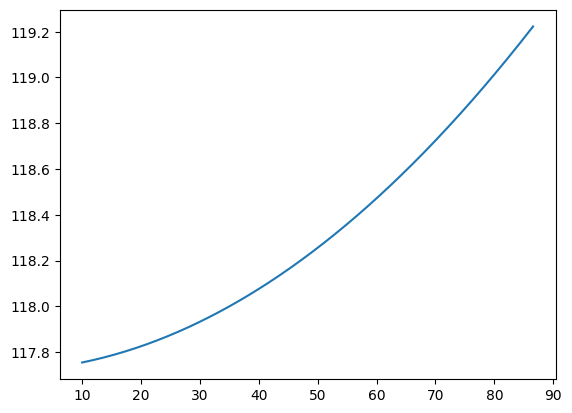

In [1131]:
plt.plot(speed, roll_resistance(speed))
plt.show()

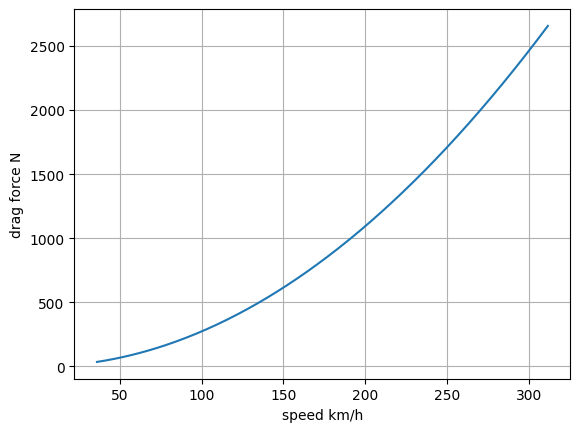

In [1132]:
plt.plot(speed*3.6, drag(speed))
plt.grid()
plt.xlabel("speed km/h")
plt.ylabel("drag force N")
plt.show()

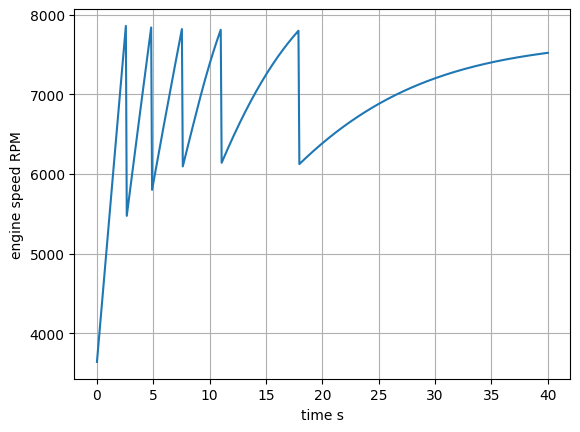

In [1133]:
plt.plot(time, N_s)
plt.xlabel("time s")
plt.ylabel("engine speed RPM")
plt.grid()
plt.show()


In [1134]:
print(N_s)

[3638.2819990807266, 3771.5898142530414, 3904.832293493894, 4038.007162871183, 4171.112153116824, 4304.1449997795435, 4437.103443376984, 4569.98522954707, 4702.788109198635, 4835.509838661282, 4968.148179834463, 5100.700900335733, 5233.165773648205, 5365.540579267116, 5497.823102845573, 5630.01113633937, 5762.102478150919, 5894.094933272246, 6025.986313427048, 6157.7744372117695, 6289.45713023572, 6421.03222526016, 6552.497562336389, 6683.850988942791, 6815.090360120808, 6946.213538609863, 7077.218394981174, 7208.102807770476, 7338.8646636096, 7469.50185735693, 7600.012292226689, 7730.393879917057, 7860.644540737115, 5473.986706493953, 5563.0299070274505, 5651.979179739589, 5740.8331244082865, 5829.590347132456, 5918.249460413853, 6006.809083238058, 6095.2678411545485, 6183.624366355884, 6271.877297755974, 6360.025281067425, 6448.066968877971, 6536.001020725963, 6623.82610317491, 6711.540889887088, 6799.144061696175, 6886.634306678926, 6974.010320225884, 7061.270805111102, 7148.4144715

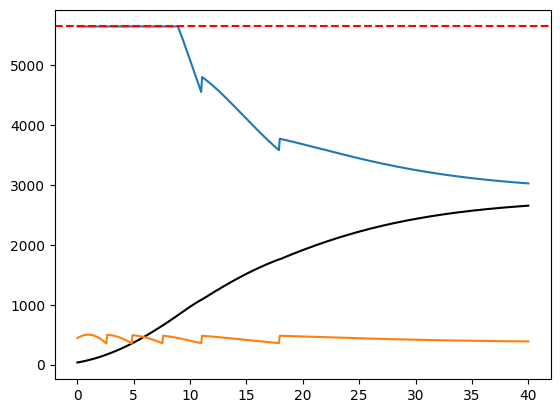

In [1135]:
plt.plot(time, tire_forces)
plt.axhline(0.6*weight*9.81*tyre_coeff, color='red', linestyle='--')
plt.plot(time, drag(speed), color='black')
plt.plot(time, crank_torque_list)
plt.show()

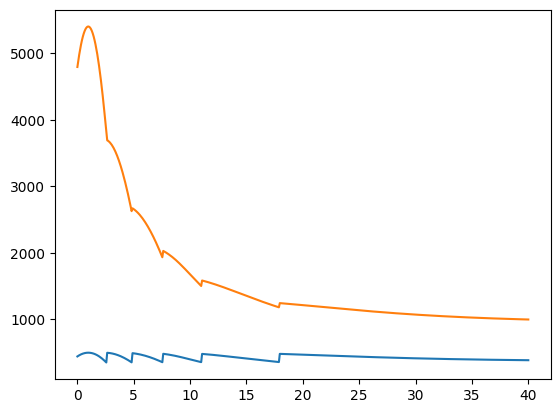

In [1136]:
plt.plot(time, crank_torque_list)
plt.plot(time, torque_at_wheel_list)
plt.show()

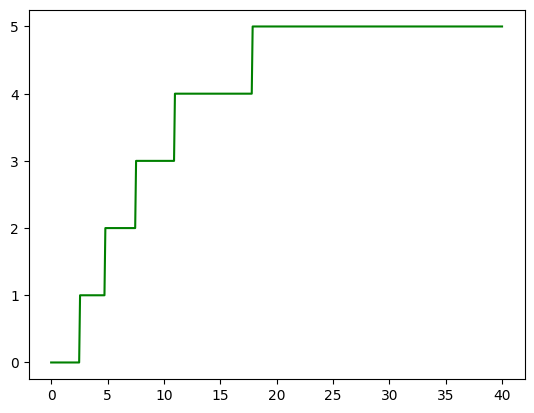

In [1137]:
plt.plot(time, gear_list, color='green')
plt.show()